In [3]:
import cv2 as cv
from cv2 import aruco
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

# --- ArUco Detector Setup ---
aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

# --- Image Paths ---
# The ArUco reference image remains constant
img_aruco_path = 'aruco_pic/aruco_0.png'
img_aruco = cv.imread(img_aruco_path)

# Find all object images recursively in dev_pictures/obj/
obj_image_paths = glob.glob('dev_pictures/obj/**/*.png')

# Rotate 180 degrees (assuming all images need this rotation)
img_aruco_rotated = cv.rotate(img_aruco, 2)

# Source coordinates defining the calibration pattern geometry
SRC_COORDS = np.array([[[0., 0.], [60., 0.], [60., 60.], [0., 60.],
                        [0., 222.], [60., 222.], [60., 282.], [0., 282.]]], dtype=np.float32)

# --- Feature Extraction Function (Kept from original) ---
def extract_features_from_contour(cnt):
    features = {}
    
    # 1. Basis-Werte
    features['area'] = cv.contourArea(cnt)
    features['perimeter'] = cv.arcLength(cnt, True)
    
    if features['area'] == 0 or features['perimeter'] == 0:
        return None
        
    # 2. Polygon Approximation & corners
    epsilon = 0.04 * features['perimeter']
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features['corners'] = len(approx)
    
    # 3. Bounding Box & aspect ratio
    x, y, w, h = cv.boundingRect(cnt)
    features['aspect_ratio'] = float(w) / h
    
    # 4. Circularity
    features['circularity'] = (4 * np.pi * features['area']) / (features['perimeter'] ** 2)
    
    # 5. Hu-Moments (shape descriptors, rotation-invariant)
    M = cv.moments(cnt)
    hu = cv.HuMoments(M).flatten()
    for i in range(7):
        features[f'hu_{i}'] = hu[i]
        
    return features

# --- Main Processing Loop ---
for img_obj_path in obj_image_paths:
    print(f"==================================================")
    print(f"Processing Image: {img_obj_path}")
    print(f"==================================================")
    
    # Load and rotate the current object image
    img_obj = cv.imread(img_obj_path)
    if img_obj is None:
        print(f"Error: Could not load image at {img_obj_path}. Skipping.")
        continue
        
    img_obj_rotated = cv.rotate(img_obj, 2)

    # --- Detect ArUco Markers (Reference Frame) ---
    corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

    if len(corners) < 2:
        print("Not enough ArUco markers detected. Cannot perform warping. Skipping feature extraction.")
        continue
        
    # --- Homography Calculation and Warping ---
    dstPoints = np.concatenate(corners, axis=1)
    H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
    H_inv = np.linalg.inv(H)

    # Define the four corners of the calibration region in pixel coordinates
    pts1 = np.float32([
        corners[1][0][0],  # oben-links
        corners[1][0][1],  # oben-rechts
        corners[0][0][3],  # unten-links
        corners[0][0][2],  # unten-rechts
    ])

    pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)
    world_frame = cv.perspectiveTransform(pts1_reshaped, H_inv)

    # Apply X/Y offsets in world coordinates (mm scale)
    offset_raw = np.array([
        [-6, +6],
        [+6, +6],
        [-6, -6],
        [+6, -6]
    ], dtype=np.float32)

    offset = offset_raw.reshape(-1, 1, 2)
    pts1_2 = world_frame + offset
    pts1_2_pixel = cv.perspectiveTransform(pts1_2, H)

    # Compute bounding dimensions for the warped region
    min_x = np.min(pts1_2_pixel[:, 0, 0])
    max_x = np.max(pts1_2_pixel[:, 0, 0])
    min_y = np.min(pts1_2_pixel[:, 0, 1])
    max_y = np.max(pts1_2_pixel[:, 0, 1])

    width = int(max_x - min_x)
    height = int(max_y - min_y)

    # Build destination points for perspective transform
    pts2_proportional = np.float32([
        [0, 0],
        [width, 0],
        [0, height],
        [width, height]
    ])
    M_warped = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

    # Warp both the ArUco image and the object image
    img_warped = cv.warpPerspective(img_aruco_rotated, M_warped, (width, height))
    dst_obj = cv.warpPerspective(img_obj_rotated, M_warped, (width, height))

    # --- Segmentation: Threshold + Contour Detection ---
    gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)
    ret, img_thresh = cv.threshold(gray_image, 150, 255, cv.THRESH_BINARY)
    uint8_img_thresh = img_thresh.astype(np.uint8)
    contours, hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

    # Visualize contours on the grayscale warped image
    img_with_contours = gray_image.copy()
    cv.drawContours(img_with_contours, contours, contourIdx=-1, color=(255, 255, 255), thickness=3)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_with_contours, cmap='gray')
    plt.title(f'Detected Contours after Perspective Warp for {os.path.basename(img_obj_path)}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Number of contours found: {len(contours)}")

    # --- Feature Extraction ---
    all_features = []
    for cnt in contours:
        if cv.contourArea(cnt) > 500:
            feat = extract_features_from_contour(cnt)
            if feat is not None:
                all_features.append(feat)

    for i, feat in enumerate(all_features):
        print(f"Object {i} in {os.path.basename(img_obj_path)}:")
        for k, v in feat.items():
            print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")
        print()

    # --- Visualize detected objects with bounding boxes and centroids ---
    img_with_objects = dst_obj.copy()
    objekte_roi = []

    for i, cnt in enumerate(contours):
        area = cv.contourArea(cnt)
        if area < 50:
            continue
            
        x, y, w, h = cv.boundingRect(cnt)
        roi = dst_obj[y:y+h, x:x+w]
        objekte_roi.append(roi)
        
        M = cv.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
        else:
            cX, cY = 0, 0
            
        cv.rectangle(img_with_objects, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv.circle(img_with_objects, (cX, cY), 5, (255, 0, 0), -1)
        cv.putText(img_with_objects, f"Obj {i} (A:{int(area)})", (x, y - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv.cvtColor(img_with_objects, cv.COLOR_BGR2RGB))
    plt.title(f'Detected Objects with Bounding Boxes and Centroids for {os.path.basename(img_obj_path)}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Display individual ROIs
    if objekte_roi:
        fig, axes = plt.subplots(1, len(objekte_roi), figsize=(15, 5))
        if len(objekte_roi) == 1:
            axes = [axes]
        for ax, roi in zip(axes, objekte_roi):
            ax.imshow(cv.cvtColor(roi, cv.COLOR_BGR2RGB))
            ax.axis('off')
        plt.suptitle(f'Individual Object ROIs for {os.path.basename(img_obj_path)}')
        plt.tight_layout()
        plt.show()

[ WARN:0@14.921] global loadsave.cpp:278 findDecoder imread_('aruco_pic/aruco_0.png'): can't open/read file: check file path/integrity


In [4]:
# --- Segmentation: Threshold + Contour Detection ---
gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)
ret, img_thresh = cv.threshold(gray_image, 150, 255, cv.THRESH_BINARY)
uint8_img_thresh = img_thresh.astype(np.uint8)
contours, hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

# Visualize contours on the grayscale warped image
img_with_contours = gray_image.copy()
cv.drawContours(img_with_contours, contours, contourIdx=-1, color=(255, 255, 255), thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')
plt.title('Detected Contours after Perspective Warp')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Number of contours found: {len(contours)}")

NameError: name 'dst_obj' is not defined

In [ ]:
# --- Feature Extraction ---
def extract_features_from_contour(cnt):
    features = {}
    
    # 1. Basis-Werte
    features['area'] = cv.contourArea(cnt)
    features['perimeter'] = cv.arcLength(cnt, True)
    
    if features['area'] == 0 or features['perimeter'] == 0:
        return None
        
    # 2. Polygon Approximation & corners
    epsilon = 0.04 * features['perimeter']
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features['corners'] = len(approx)
    
    # 3. Bounding Box & aspect ratio
    x, y, w, h = cv.boundingRect(cnt)
    features['aspect_ratio'] = float(w) / h
    
    # 4. Circularity
    features['circularity'] = (4 * np.pi * features['area']) / (features['perimeter'] ** 2)
    
    # 5. Hu-Moments (shape descriptors, rotation-invariant)
    M = cv.moments(cnt)
    hu = cv.HuMoments(M).flatten()
    for i in range(7):
        features[f'hu_{i}'] = hu[i]
        
    return features

# Extract features from all contours with area > 500 (filter noise)
all_features = []
for cnt in contours:
    if cv.contourArea(cnt) > 500:
        feat = extract_features_from_contour(cnt)
        if feat is not None:
            all_features.append(feat)

for i, feat in enumerate(all_features):
    print(f"Object {i}:")
    for k, v in feat.items():
        print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")
    print()

Object 0:
  area: 32718.000000
  perimeter: 1236.513842
  corners: 6
  aspect_ratio: 1.243363
  circularity: 0.268905
  hu_0: 0.220884
  hu_1: 0.005786
  hu_2: 0.002926
  hu_3: 0.000344
  hu_4: 0.000000
  hu_5: 0.000025
  hu_6: 0.000000



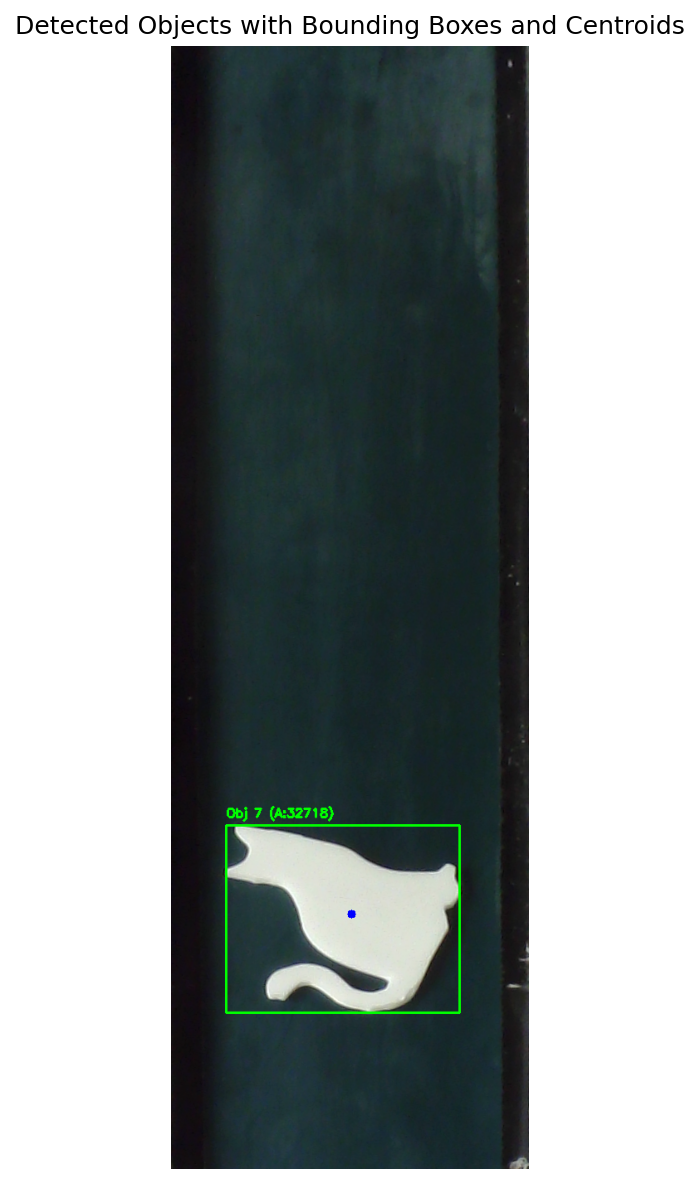

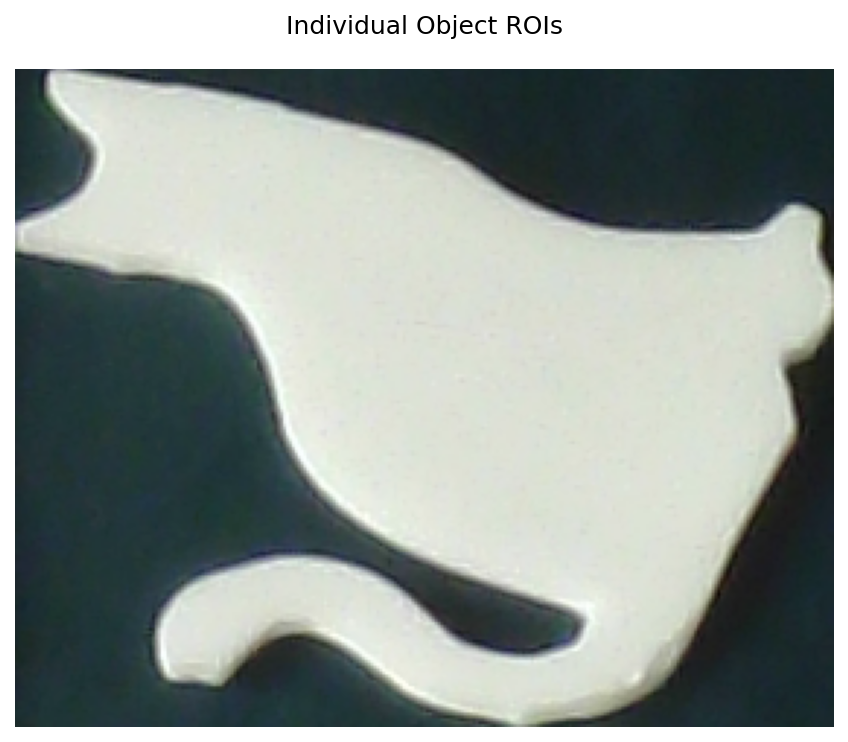

In [ ]:
# --- Visualize detected objects with bounding boxes and centroids ---
img_with_objects = dst_obj.copy()
objekte_roi = []

for i, cnt in enumerate(contours):
    area = cv.contourArea(cnt)
    if area < 50:
        continue
        
    x, y, w, h = cv.boundingRect(cnt)
    roi = dst_obj[y:y+h, x:x+w]
    objekte_roi.append(roi)
    
    M = cv.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0
        
    cv.rectangle(img_with_objects, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv.circle(img_with_objects, (cX, cY), 5, (255, 0, 0), -1)
    cv.putText(img_with_objects, f"Obj {i} (A:{int(area)})", (x, y - 10),
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_with_objects, cv.COLOR_BGR2RGB))
plt.title('Detected Objects with Bounding Boxes and Centroids')
plt.axis('off')
plt.tight_layout()
plt.show()

# Display individual ROIs
if objekte_roi:
    fig, axes = plt.subplots(1, len(objekte_roi), figsize=(15, 5))
    if len(objekte_roi) == 1:
        axes = [axes]
    for ax, roi in zip(axes, objekte_roi):
        ax.imshow(cv.cvtColor(roi, cv.COLOR_BGR2RGB))
        ax.axis('off')
    plt.suptitle('Individual Object ROIs')
    plt.tight_layout()
    plt.show()